In [1]:
import pandas as pd
import numpy as np
import sys

def exit_with_error(message):
    print(f"Error: {message}")
    sys.exit(1)

metadata_fname = "metadata/metadata_wide.tsv"
quants_fname = "data/precursors_normalized_wide.tsv"

metadata = pd.read_csv(metadata_fname, sep='\t', na_values=['NA'])
data = pd.read_csv(quants_fname, sep='\t')
data = data.fillna(0)
protein_names = data['protein'].values
peptides = data['modifiedSequence'].values

print("Metadata shape:", metadata.shape)
print("Data shape:", data.shape)

Metadata shape: (104, 25)
Data shape: (15969, 107)


Data shape: (86, 15969)
Months: [22.42 14.37 14.37 17.36 11.15  5.85 22.42 29.33 22.42 20.48 17.46  5.85
 14.37  8.15 11.15 22.42 30.25 27.   14.37 20.48  5.85  5.85 27.   17.46
 29.33 11.15 20.48  8.15  8.15 17.46 20.58 11.15 27.   22.42 17.46 11.15
 14.37  5.85  8.15 29.33  8.15 22.42 27.   22.42  5.85 11.15  5.85 22.42
 17.46 30.25 20.48  5.85 20.58 17.36  8.15 14.37  8.15 11.15 14.37 22.42
 17.46  8.15 11.15  5.85 22.42 14.37  5.85 20.48 20.48 27.   20.48 17.46
  8.15 29.33 11.15 22.42 20.48 27.   14.37 30.25 14.37 17.36  8.15 11.15
 27.   22.42]
Sex: [0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 0 1 0 1 1 1 0 0 1 1 1 0 0 0 0 0 0 1 1 0
 1 1 0 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0
 0 1 0 0 0 1 1 1 0 1 1 1]


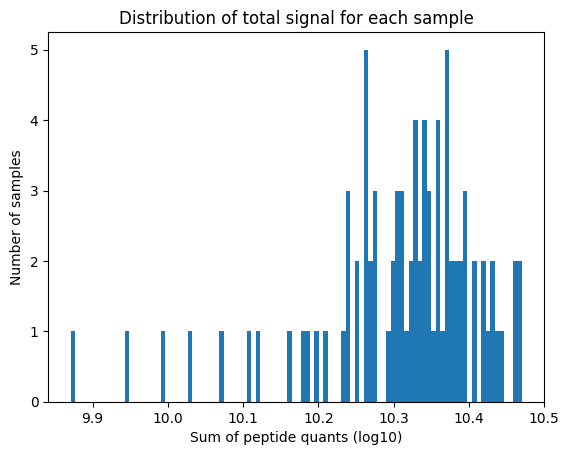

In [2]:
import matplotlib.pyplot as plt

valid_replicates = metadata[metadata['Age_months'].notna()]['replicate'].tolist()

X = []
month = []
sex = []

for idx in valid_replicates:
  for sample in data.columns[:]:
    if idx in sample:
      s_month = metadata[metadata['replicate'] == idx]['Age_months'].values[0]
      s_sex = metadata[metadata['replicate'] == idx]['Sex'].values[0]

      month.append(s_month)
      sex.append(s_sex)
      X.append(data[sample].values)

X = np.array(X)
X = np.power(2, X) # "unlog" X

month = np.array(month)
month = month.astype(float)

sex = np.array(sex)
sex = np.where(sex == "Male", 0, 1) # encode the sex array
sex = sex.astype(int)

print("Data shape:", X.shape)
print("Months:", month)
print("Sex:", sex)

total_signal = np.sum(X, axis=1)
plt.hist(np.log10(total_signal), bins = 100)
plt.title('Distribution of total signal for each sample')
plt.ylabel('Number of samples')
plt.xlabel('Sum of peptide quants (log10)')
plt.show()

In [3]:
import numpy as np

def deduplicate_peptides(data_array, peptide_labels, protein_labels):
    """
    Remove duplicate peptide columns from a 2D array and update corresponding labels.
    
    Parameters:
    -----------
    data_array : numpy.ndarray
        2D array with samples as rows and peptides as columns
    peptide_labels : numpy.ndarray
        1D array of peptide labels corresponding to columns
    protein_labels : numpy.ndarray  
        1D array of protein labels corresponding to columns
        
    Returns:
    --------
    tuple : (updated_data_array, updated_peptide_labels, updated_protein_labels)
        - updated_data_array: 2D array with duplicate peptide columns removed
        - updated_peptide_labels: 1D array of unique peptide labels
        - updated_protein_labels: 1D array of merged protein labels (comma-delimited)
    """
    
    # Find unique peptides and their first occurrence indices
    unique_peptides, unique_indices = np.unique(peptide_labels, return_index=True)
    
    # Create a mapping from peptide to all its protein labels
    peptide_to_proteins = {}
    
    for i, peptide in enumerate(peptide_labels):
        if peptide not in peptide_to_proteins:
            peptide_to_proteins[peptide] = []
        peptide_to_proteins[peptide].append(protein_labels[i])
    
    # Create merged protein labels for unique peptides
    updated_protein_labels = []
    for peptide in unique_peptides:
        # Get unique proteins for this peptide and join with commas
        unique_proteins = list(set(peptide_to_proteins[peptide]))
        merged_protein = ','.join(sorted(unique_proteins))
        updated_protein_labels.append(merged_protein)
    
    # Sort indices to maintain original order
    sorted_indices = np.sort(unique_indices)
    
    # Extract the corresponding columns from the data array
    updated_data_array = data_array[:, sorted_indices]
    
    # Get the peptide labels in the same order
    updated_peptide_labels = peptide_labels[sorted_indices]
    
    # Reorder protein labels to match
    peptide_to_merged_protein = dict(zip(unique_peptides, updated_protein_labels))
    updated_protein_labels = [peptide_to_merged_protein[peptide] for peptide in updated_peptide_labels]
    
    return updated_data_array, np.array(updated_peptide_labels), np.array(updated_protein_labels)

In [4]:
print(X.shape)
X, peptides, protein_names = deduplicate_peptides(X, peptides, protein_names)
print(X.shape)

(86, 15969)
(86, 15197)


In [5]:
peptides = np.array([f"{x} ({y})" for x, y in zip(peptides, protein_names)])

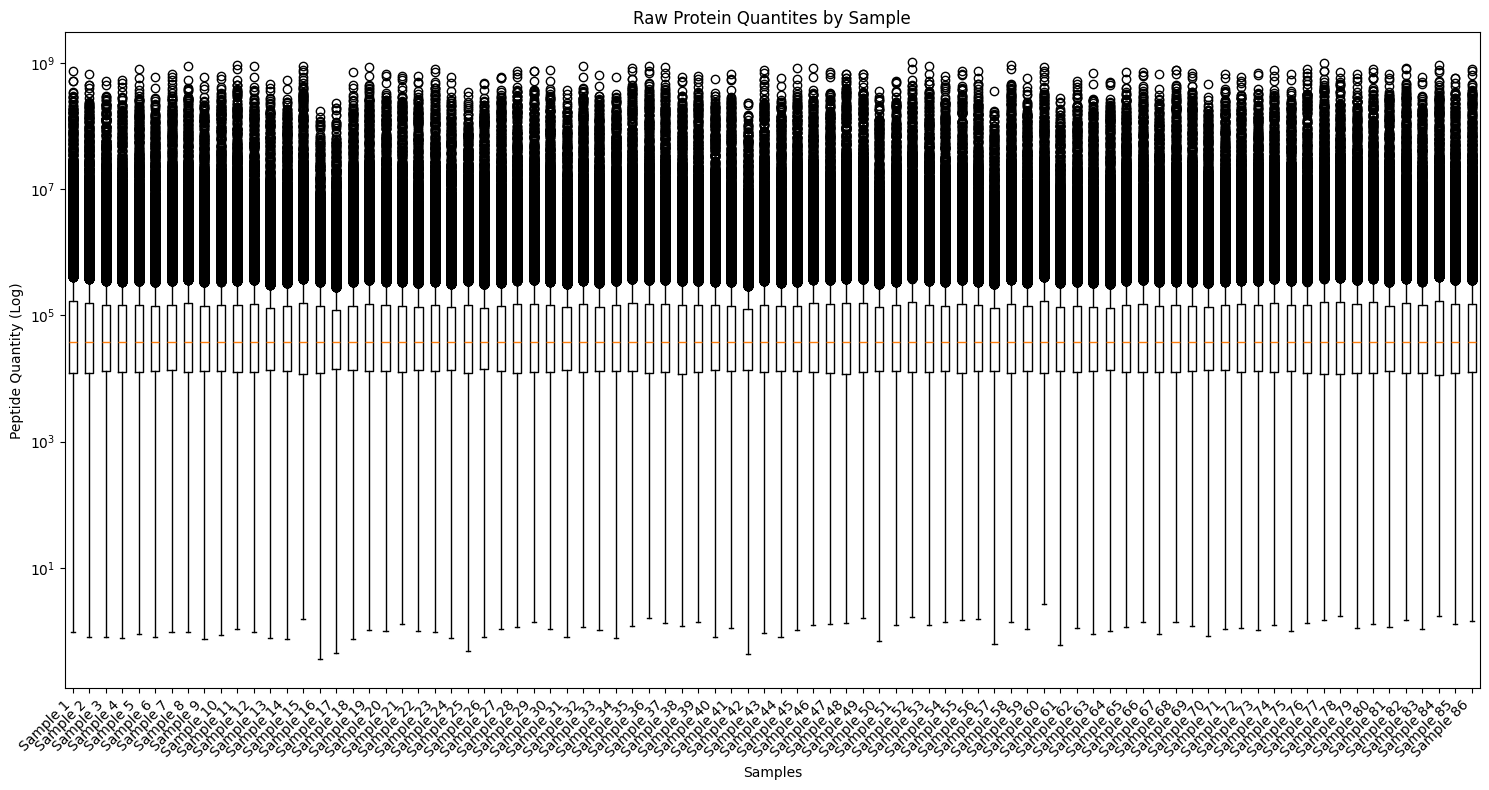

In [6]:
# Create the box plot
plt.figure(figsize=(15, 8))
plt.boxplot(X.T)  # Transpose the data

plt.title('Raw Protein Quantites by Sample')
plt.xlabel('Samples')
plt.ylabel('Peptide Quantity (Log)')
plt.xticks(range(1, X.shape[0] + 1), [f'Sample {i+1}' for i in range(X.shape[0])], rotation=45, ha='right')

# Use log scale for y-axis as peptide quantities often span several orders of magnitude
plt.yscale('log')

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

In [7]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm


def analyze_proteins_vs_age(
    X: np.ndarray,
    month: np.ndarray,
    sex: np.ndarray,
    protein_names: np.ndarray,
    alpha: float = 0.01,
) -> pd.DataFrame:
    """
    Test whether each protein’s abundance changes with age (month),
    controlling for sex, using ordinary least-squares regression.

    Parameters
    ----------
    X : (n_samples, n_proteins) ndarray
        Protein intensities (preferably log-scaled).
    month : (n_samples,) array-like
        Numeric age in months.
    sex : (n_samples,) array-like
        Sex labels; converted to a categorical predictor.
    protein_names : (n_proteins,) array-like
        Column names for X.
    alpha : float, default 0.01
        Significance level used for confidence intervals and FDR flag.

    Returns
    -------
    results_df : pandas.DataFrame
        One row per protein with coefficient, SE, p-value, BH-adjusted q-value,
        100 × (1 – alpha) % confidence interval, and significance flag.
    """
    # ------------- input checks ------------------------------------------------
    n_samples, n_proteins = X.shape
    if len(month) != n_samples or len(sex) != n_samples:
        raise ValueError("month and sex must have the same length as X’s rows.")
    if len(protein_names) != n_proteins:
        raise ValueError("protein_names length must equal number of columns in X.")

    month = np.asarray(month, dtype=float)
    sex_cat = pd.Categorical(sex)
    zcrit = norm.ppf(1 - alpha / 2)

    rows = []

    # ------------- per-protein OLS --------------------------------------------
    for j, pname in enumerate(protein_names):
        df = pd.DataFrame(
            {"protein": X[:, j], "month": month, "sex": sex_cat}
        )

        try:
            fit = smf.ols("protein ~ month + sex", data=df).fit()

            beta = fit.params["month"]
            se = fit.bse["month"]
            pval = fit.pvalues["month"]

            rows.append(
                dict(
                    protein=pname,
                    coef_month=beta,
                    std_err=se,
                    p_value=pval,
                    ci_lower=beta - zcrit * se,
                    ci_upper=beta + zcrit * se,
                    minus_log10_p=-np.log10(pval),
                )
            )

        except Exception as err:
            rows.append(
                dict(
                    protein=pname,
                    coef_month=np.nan,
                    std_err=np.nan,
                    p_value=np.nan,
                    ci_lower=np.nan,
                    ci_upper=np.nan,
                    minus_log10_p=np.nan,
                    error=str(err),
                )
            )

    results_df = pd.DataFrame(rows).sort_values("p_value", na_position="last")

    # ------------- Benjamini–Hochberg FDR -------------------------------------
    valid = results_df["p_value"].notna()
    if valid.any():
        qvals = multipletests(results_df.loc[valid, "p_value"], method="fdr_bh")[1]
        results_df.loc[valid, "q_value"] = qvals
        results_df["signif_FDR<{:.3f}".format(alpha)] = results_df["q_value"] < alpha

    return results_df


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

def create_volcano_plot(results_df, top_n: int = 10, alpha: float = 0.01,
                        save_path: str | None = None):
    """
    Volcano plot for the output of `analyze_proteins_vs_age`.

    Parameters
    ----------
    results_df : pandas.DataFrame
        Must contain, at a minimum:
            • 'coef_month'  ........ slope of age in the reference sex
            • 'q_value'     ........ BH-adjusted p-value (FDR)
            • dynamically-named significance flag: 'signif_FDR<0.010' if alpha=0.01
            • 'protein'     ........ protein identifiers
    top_n : int, default 10
        Number of top proteins (by –log10 q-value) to label.
    alpha : float, default 0.01
        Same α that was supplied to `analyze_proteins_vs_age`; used only to
        draw the horizontal FDR threshold and to find the significance column.
    save_path : str | None
        If given, the figure is saved instead of shown.

    Returns
    -------
    matplotlib.figure.Figure
    """
    if results_df.empty:
        print("No results to visualise.")
        return None

    # Detect column names ------------------------------------------------------
    coef_col = "coef_month"
    q_col    = "q_value"
    prot_col = "protein"

    # significance flag column has name like 'signif_FDR<0.010'
    sig_cols = [c for c in results_df.columns if c.startswith("signif_FDR")]
    if not sig_cols:
        raise ValueError("Significance flag column (signif_FDR<α) not found.")
    sig_flag_col = sig_cols[0]

    # –log10(q-value) column ---------------------------------------------------
    results_df = results_df.copy()
    results_df["minus_log10_q"] = -np.log10(results_df[q_col].replace(0, 1e-300))

    sig_df    = results_df[results_df[sig_flag_col]]
    nonsig_df = results_df[~results_df[sig_flag_col]]

    # Plot ---------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.scatter(nonsig_df[coef_col], nonsig_df["minus_log10_q"],
               s=20, alpha=0.6, label="Not significant (FDR)")
    ax.scatter(sig_df[coef_col], sig_df["minus_log10_q"],
               s=20, alpha=0.9, label="Significant (FDR)")

    # Horizontal FDR line
    ax.axhline(-np.log10(alpha), ls="--", color="grey",
               label=f"FDR = {alpha:g}")

    # Label top N proteins -----------------------------------------------------
    top_prots = results_df.nlargest(top_n, "minus_log10_q")
    texts = [
        ax.text(row[coef_col], row["minus_log10_q"], row[prot_col],
                fontsize=8, ha="center", va="bottom")
        for _, row in top_prots.iterrows()
    ]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="->", lw=0.5))

    # Cosmetics
    ax.set_xlabel("Coefficient for age (slope)")
    ax.set_ylabel("-log10(FDR-adjusted p-value)")
    ax.set_title("Volcano plot: peptide abundance vs age")
    ax.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()

    return fig


In [9]:
from sklearn.preprocessing import StandardScaler

# Log transformation to reduce skewness
X_log = np.log1p(X)

# Standard scaling to normalize the range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

In [10]:
# Analyze proteins
results = analyze_proteins_vs_age(X_scaled, month, sex, peptides)

# Print top results
print("Top 10 peptides associated with month:")
print(results.head(20)[['protein', 'coef_month', 'p_value', 'q_value']])

Top 10 peptides associated with month:
                                                 protein  coef_month  \
14561          DIVMTQSPTFLAVTASK (sp|P01632|KV1A1_MOUSE)   -0.093118   
14644                 AFLVGALTMR (sp|D3Z7H8|CILP2_MOUSE)   -0.090451   
3735              ALMAYAFALAGNQNK (sp|P28665|MUG1_MOUSE)   -0.060973   
3745   MLSGFIPLKPTVK (sp|P28665|MUG1_MOUSE,sp|P28666|...   -0.057782   
3709     VPNAMSVNDEVLSVTAC[+57]GK (sp|P28665|MUG1_MOUSE)   -0.058316   
3724   HTSSWLVTPK (sp|P28665|MUG1_MOUSE,sp|P28666|MUG...   -0.056518   
3741              TTLVTIQSTGSFSQK (sp|P28665|MUG1_MOUSE)   -0.058803   
14121                 VTIPGNYYK (tr|E9Q0B5|E9Q0B5_MOUSE)   -0.085614   
14117                   LEQSQWK (tr|E9Q0B5|E9Q0B5_MOUSE)   -0.085172   
3732                  SSGSLFNNAMK (sp|P28665|MUG1_MOUSE)   -0.054603   
3730   EGNTWLTAFVLK (sp|P28665|MUG1_MOUSE,sp|P28666|M...   -0.058825   
3713                  HVAYAVYSLSK (sp|P28665|MUG1_MOUSE)   -0.055453   
3742   FQVENSNR (sp|P2866

In [11]:
# output features to disk
results.to_csv("results/peptides-mouse-aging-features-ols.csv", index=False)

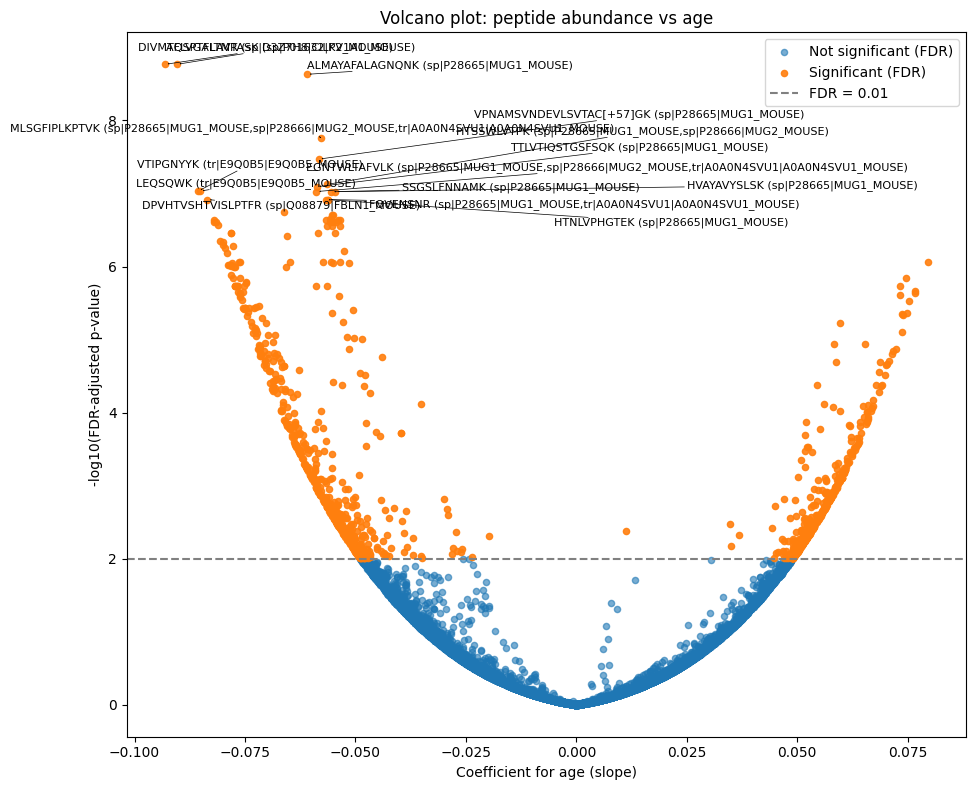

In [12]:
# Visualize results
create_volcano_plot(results, top_n=15)
plt.show()